In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from kneed import KneeLocator
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
plt.rcParams['font.sans-serif'] = ['Arial']
plt.style.use("seaborn-v0_8-talk")
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

<div class="jumbotron">
    <h1 class="display-1">Clustering I</h1>
    <hr class="my-4">
    <p>Instructor: Dr. Yan Li</p>
</div>

## Business Question: Why Do We Need Clustering?

### The Blind Marketing Campaign

<center><img src="./img/clustering/blind_vs_clustered.png" width="60%"></center>

Imagine you are consulting for a **300-room urban boutique hotel**. 
The general manager says: *"We have a $10,000 digital ad budget. Half our guests are budget-hunters and half are luxury spenders, so let's just split the budget 50/50."*

<div class="alert alert-warning">
    <strong>The Risk:</strong> This is "Blind Marketing." If you message a luxury traveler with a "budget burger deal," you lose prestige. If you message a budget traveler with a "$200 spa credit," you waste your ad spend.
</div>

### Participation Challenge: Can you find the groups?

Below are 10 guests. In your mind (or on paper), try to group them into **two types**. 


| Guest ID | Stay Duration (Days) | Daily Spend (ADR, \$) | Total Spend (\$) |
|---|---|---|---|
| G001 | 2 | \$320 | \$640 |
| G002 | 7 | \$110 | \$770 |
| G003 | 1 | \$340 | \$340 |
| G004 | 4 | \$210 | \$840 |
| G005 | 6 | \$120 | \$720 |
| G006 | 2 | \$295 | \$590 |
| G007 | 3 | \$205 | \$615 |
| G008 | 1 | \$350 | \$350 |
| G009 | 5 | \$115 | \$575 |
| G010 | 3 | \$220 | \$660 |


**Discussion Question:** Is G004 ($210 ADR, 4 days) a "luxury" or "budget" guest?

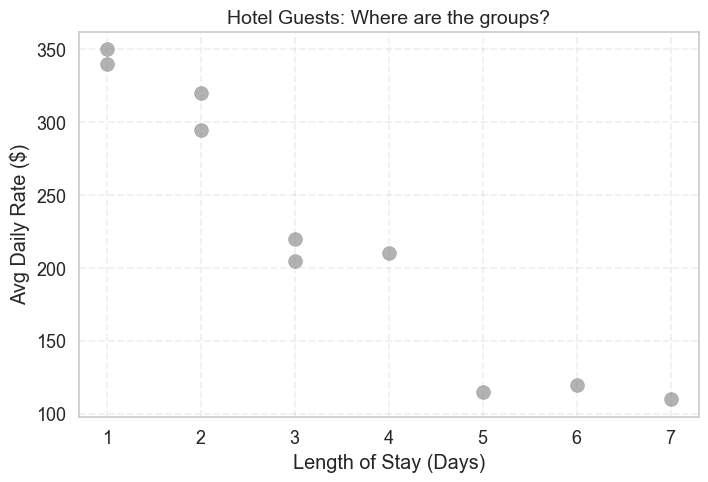

In [3]:
# --- Visualizing the "Blind" Table ---
import matplotlib.pyplot as plt

# The 10 guests from the table above
duration = [2, 7, 1, 4, 6, 2, 3, 1, 5, 3]
adr = [320, 110, 340, 210, 120, 295, 205, 350, 115, 220]

plt.figure(figsize=(8, 5))
plt.scatter(duration, adr, color='gray', s=100, alpha=0.6)
plt.title("Hotel Guests: Where are the groups?", fontsize=14)
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Avg Daily Rate ($)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show();

### Why Manual Sorting Fails

<center><img src="./img/clustering/manual_vs_machine.png" width="50%"></center>


- **The Threshold Trap:** If you set a split at $\$250$ ADR, what happens to the guest at $\$249$? They are lumped with the "budget" group, even though they behave almost exactly like the "luxury" group.
- **The Dimensionality Trap:** Real hotels track 20+ variables (Stay length, Lead time, Cancellations, Spa spend). You cannot "see" 20 dimensions in a table.

<div class="alert alert-danger">
    <strong>Manual scanning is O(n):</strong> It scales poorly. Scanning 5,000 guests manually is a full-time job; doing it for 20 variables is a nightmare.
</div>

### The Solution: Unsupervised Machine Learning

<div class="alert alert-info">
    <strong>Key Insight:</strong> When manual boundary-drawing fails,
    we need an algorithm that can find natural groupings in the data
    <strong>without predefined labels</strong>.
</div>

This is exactly what **clustering algorithms** like **K-Means** do — they discover hidden "Personas" in unlabeled guest data by measuring mathematical similarity across multiple features simultaneously.

<div class="alert alert-success">
    In business, we don't just want clusters; we want <strong>Personas</strong>. A cluster is just math; a Persona is a group we can build a marketing story around.
</div>

- Goal: customers with similar characteristics belong to the same group; customers with different characteristics are assigned to different groups

## Applications of Clustering Analysis

### Customer Segmentation (CRM & Marketing)

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">An e-commerce platform has 1M users with purchase history, browsing behavior, and demographics. The CMO wants <strong>5-7 marketing personas</strong> for targeted campaigns.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: avg order value, purchase frequency, product category preferences, time since last purchase</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Clusters like "High-Value Frequent Buyers," "Discount-Seeking Shoppers," "Window Shoppers" enable personalized email campaigns, increasing conversion rates by <strong>20-40%</strong>.</dd>
</dl>

**Real Company:** Amazon, Netflix, and Spotify all use clustering for recommendation and personalization.

### Retail Store Clustering (Merchandising)

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A retail chain with 500 stores wants to group stores by <strong>sales pattern similarity</strong> to optimize inventory allocation.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: weekly revenue, product category mix, foot traffic, store size, regional demographics</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Clusters like "Urban Flagship Stores," "Suburban Family Stores," "Seasonal Tourist Stores" guide regional marketing budgets and stock levels, reducing inventory waste by <strong>15-25%</strong>.</dd>
</dl>

**Real Company:** Walmart uses store clustering to customize product assortments by location.

### Patient Stratification (Healthcare)

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A hospital wants to identify patient subpopulations with <strong>similar disease progression patterns</strong> for personalized treatment plans.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: lab test results, age, BMI, medication adherence, readmission history, genetic markers</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Clusters like "Low-Risk Recovery," "Chronic Management Needed," "High-Risk Readmission" enable targeted interventions, reducing hospital readmission rates by <strong>20%</strong>.</dd>
</dl>

**Real Application:** COVID-19 patient clustering helped hospitals allocate ICU resources based on symptom severity patterns.

### Image & Document Clustering (Computer Vision)

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A photo library with 10M images needs <strong>automatic album creation</strong> without manual tagging.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: pixel color histograms, edge detection features, embedded vectors from a pre-trained CNN (e.g., ResNet)</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Clusters like "Beach Photos," "City Landmarks," "Family Portraits" — Google Photos clusters 1B+ images daily for auto-generated albums.</dd>
</dl>

**Real Application:** Handwriting recognition systems cluster similar handwritten characters before classification (used in postal mail sorting).

### Anomaly & Fraud Detection (Finance)

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A credit card company processes 100M transactions/day. The fraud team needs to flag <strong>unusual spending patterns</strong> in real-time.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: transaction amount, merchant category, time of day, location, device fingerprint, user's historical behavior</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Normal transactions form dense clusters; fraud transactions appear as <strong>isolated outliers</strong> far from any cluster. This catches <strong>$10B+</strong> in annual fraud for major banks.</dd>
</dl>

**Real Company:** PayPal uses clustering-based anomaly detection to flag suspicious account behavior.

### Document Organization & Web Search

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A search engine returns 10M results for "machine learning." Users need <strong>categorized results</strong> by subtopic, not one long list.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: TF-IDF vectors, word embeddings (Word2Vec/BERT) representing document content</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Clusters like "Deep Learning Papers," "Statistical Learning Theory," "Industry Applications" help users navigate results efficiently — Google News uses clustering to group related articles.</dd>
</dl>

**Real Application:** Carrot2 is an open-source search results clustering engine used by major libraries.

### Social Network Community Detection

<dl class="row">
    <dt class="col-md-3 text-primary">Scenario</dt>
    <dd class="col-md-9">A social media platform with 500M users wants to identify <strong>communities of interest</strong> for content recommendation.</dd>
    <dt class="col-md-3 text-primary">Clustering Input</dt>
    <dd class="col-md-9">Features: graph adjacency (who follows whom), interaction frequency, shared group memberships, content engagement patterns</dd>
    <dt class="col-md-3 text-primary">Business Impact</dt>
    <dd class="col-md-9">Communities like "Tech Enthusiasts," "Fitness Community," "Local Events" drive <strong>2-3x higher engagement</strong> through targeted content feeds.</dd>
</dl>

**Real Company:** LinkedIn uses clustering for "People You May Know" recommendations and industry group suggestions.

## Basic Concepts

### Definition of clustering

<dl class="row alert-info">
    <dt class="col-md-2">clustering</dt>
    <dd class="col-md-10">An unsupervised algorithm that groups similar samples together, separating samples with different characteristics</dd>
</dl>

- Each group formed is called a **cluster**

- Goal: samples within a cluster are ***as similar as possible***; samples from different clusters are ***as different as possible***.

<img src="./img/clustering/clustering.png" width=100%>

### Clustering Methods

- **K-Means**
    - **Type**: **Non-nested** (Partitional)
    - **Membership**: **Exclusive** (Non-overlapping)
    - **Coverage**: **Complete** (Every point assigned to a cluster)
    - *Similarity*: Distance-based (Centroids)

- Divides data into **non-overlapping** subsets (clusters); each object belongs to **exactly** one cluster

<img src="./img/clustering/partition.png" width=30%>

- **Hierarchical Clustering**
    - **Type**: **Nested** (Hierarchical tree)
    - **Membership**: **Exclusive** (at any given level)
    - **Coverage**: **Complete** (All points eventually merge into root)
    - *Logic*: Iterative merging (Agglomerative) or splitting (Divisive)

<img src="./img/clustering/hierarchical.png" width=70%>

- **Density-Based Methods (DBSCAN)**
    - **Type**: **Non-nested** (Partitional)
    - **Membership**: **Exclusive**
    - **Coverage**: **Partial** (**Noise points** are not assigned to any cluster)
    - *Logic*: Connectivity based on density thresholds

- A cluster is a **dense region** of objects, separated by low-density regions (noise) from other clusters

<img src="./img/clustering/densityBased.png" width=70%>

|Method| Type (Nested?)| Membership | Coverage (Partial?)|
|---|---|---|---|
|K-Means|Non-nested|Exclusive |Complete|
|Hierarchic|Nested|Exclusive|Complete|
|Density-Ba|Non-nested|Exclusive|Partial|

## K-Means

- Measure similarity by distance between samples and find compact, well-separated clusters
  - For continuous variables, use the **centroid** (mean) as the cluster center 
  - For categorical variables, use the **medoid** (the most representative or most frequent point) as the the cluster center 

### Algorithm

<center><img src='./img/clustering/kmago_en.svg' width=60%></center>

##### K-Means Clustering Process — Example

<center><img src="./img/clustering/kmeansProcess.gif" width=100%></center>

#### Distance Metrics

- Euclidean space: Euclidean distance between two points $\boldsymbol{x}$ and $\boldsymbol{y}$ in $n$-dimensional space:
$$
d(\boldsymbol{x}, \boldsymbol{y}) =\sqrt{(x_1-y_1)^2+(x_2-y_2)^2+\cdots+(x_n-y_n)^2}
$$

#### Objective Function

- Objective: minimize the sum of squared errors (SSE), i.e., the Euclidean distance from each point to its nearest centroid

$$
\begin{split}
SSE &= \sum_{i=1}^K\sum_{\boldsymbol{x}\in C_i}d(\boldsymbol{c}_i, \boldsymbol{x})^2\\
\boldsymbol{c}_i&=\frac{1}{m_i}\sum_{\boldsymbol{x}\in C_i}\boldsymbol{x}
\end{split}
$$
where $\boldsymbol{x}$ is a data point, $C_i$ is the $i$-th cluster, $c_i$ is the centroid of $C_i$, $m_i$ is the number of points in $C_i$, and $K$ is the number of clusters

- Within-cluster SSE is also called ***cluster inertia***

#### Initial Centroids

- Randomly select $K$ samples as initial centroids

- Initial centroid selection significantly affects clustering results

<p class="h3">Good Initial Centroids</p>
<center><img src="./img/clustering/kmeansProcess.gif" width=100%></center>

<p class="h3">Poor Initial Centroids</p>
<center><img src="./img/clustering/kmeansInitialCentroid.gif" width=100%></center>

##### Improving Initial Centroid Selection

<p class="h3">K-Means++ Initialization</p>

- Sequentially select $k$ initial centroids

- Main Idea
    + 1) Initialize empty set $\boldsymbol{M}$ to store $k$ centroids
    + 2) Randomly pick first centroid $\boldsymbol{\mu}_j$, add to $\boldsymbol{M}$
    + 3) For each $\boldsymbol{x}_i$ not in $M$, compute min squared distance to centroids in $M$: $d(\boldsymbol{x}_i,\boldsymbol{M})^2$
    + 4) The next centroid $\boldsymbol{\mu}_p$ is selected with probability:
    $$
    \frac{d(\boldsymbol{\mu}_p,\boldsymbol{M})^2}{\sum_{i=1}^Nd(\boldsymbol{x}_i,\boldsymbol{M})^2}
    $$
    + 5) Repeat steps 3) and 4) until $k$ initial centroids are selected

- Advantage
    + Ensures both randomness and dispersion of initial centroids

### K-Means Implementation in Python

```python
from sklearn.cluster import KMeans
KMeans(n_clusters=8, init=’k-means++’, max_iter=300, random_state=None)
```
- `n_clusters`: `int`, number of clusters
- `init`: initial centroid method: `k-means++` or `random`
- `max_iter`: maximum iterations
- `random_state`: random seed for initial centroids

#### Building a K-Means Clustering Model

##### Loading the hotel_marketing Dataset

In [4]:
hotdf = pd.read_csv('data/analysis/hotel_bookings.csv')
hotdf['Stay_Duration_Days'] = hotdf['stays_in_weekend_nights'] + hotdf['stays_in_week_nights']
hotdf['Daily_Spend_ADR'] = hotdf['adr']
hotdf['Total_Spend'] = hotdf['Stay_Duration_Days'] * hotdf['Daily_Spend_ADR']
hotdf = hotdf[hotdf['Total_Spend'] > 0] # Filter out zero spend
hotdf = hotdf.select_dtypes(include='number')
hotdf.isna().sum(axis=0)

is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
booking_changes                        0
agent                              15391
company                           111051
days_in_waiting_list                   0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
Stay_Duration_Days                     0
Daily_Spend_ADR                        0
Total_Spend                            0
dtype: int64

In [5]:
hotdf.drop(columns=['agent','company'], inplace=True)
hotdf.fillna({'children':hotdf['children'].mean()},inplace=True)
hotdf.head()
hotdf.shape

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,Stay_Duration_Days,Daily_Spend_ADR,Total_Spend
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,75.0,0,0,1,75.0,75.0
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,75.0,0,0,1,75.0,75.0
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,98.0,0,1,2,98.0,196.0
5,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,98.0,0,1,2,98.0,196.0
6,0,0,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,107.0,0,0,2,107.0,214.0


(117430, 21)

##### Boxplot of Features — Check Value Ranges

<Axes: >

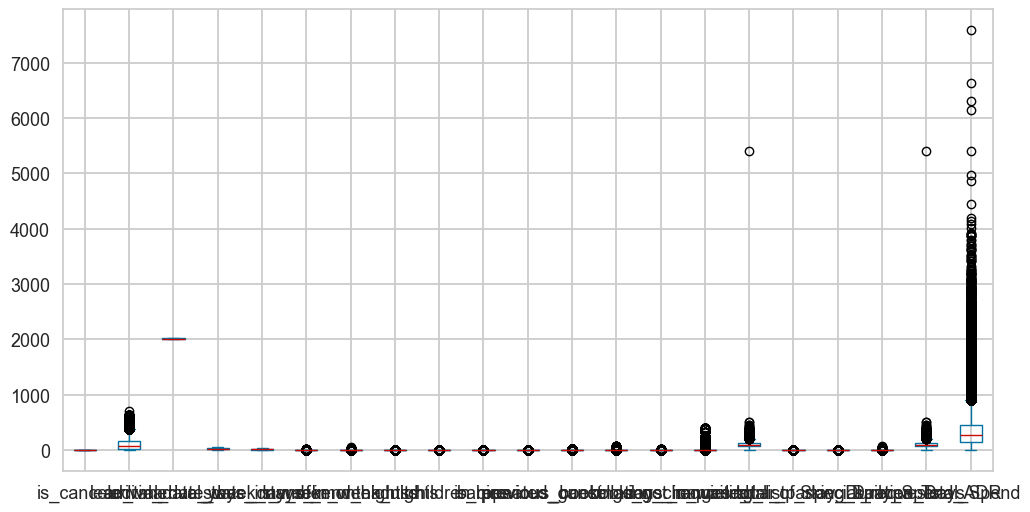

In [6]:
hotdf.plot(kind='box',figsize=(12,6))

- Both features have incomparable ranges; need standardization

##### Standardization of Features

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(hotdf)

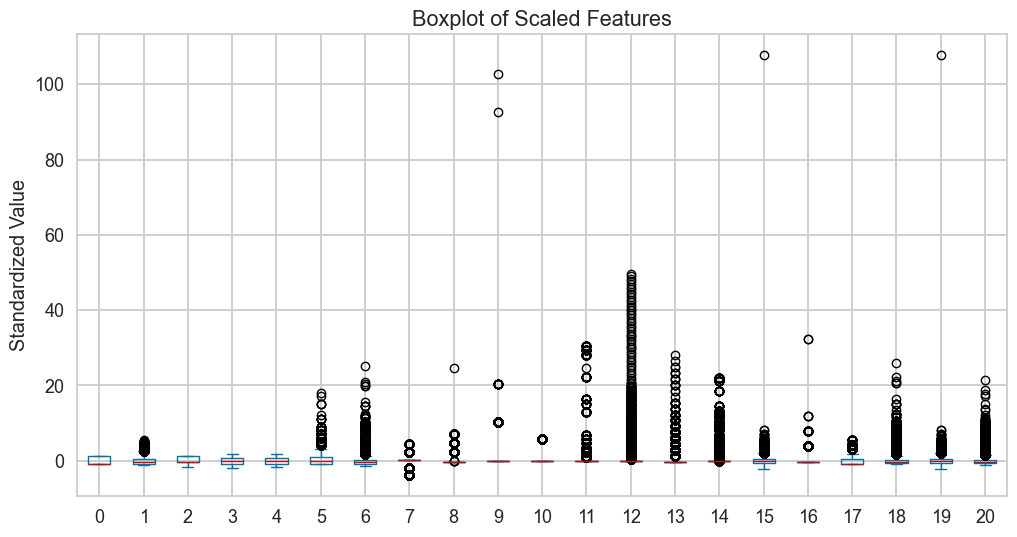

In [9]:
scaled_df = pd.DataFrame(scaled_features)
scaled_df.plot(kind='box', figsize=(12, 6))
plt.title('Boxplot of Scaled Features')
plt.ylabel('Standardized Value')
plt.show();

##### Build the Clustering Model

In [10]:
hotKmeans = KMeans(n_clusters=2,random_state=0)
hotKmeans

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


#### Training the K-Means Model

```python
kmeans.fit(X)
```
- `X`: the dataset containing the features to cluster

In [11]:
hotKmeans.fit(scaled_df)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


##### Attributes of the Trained Model

- `labels_`: cluster label for each sample

In [12]:
hotKmeans.labels_

array([1, 1, 1, ..., 0, 0, 0], shape=(117430,), dtype=int32)

- `inertia_`: within-cluster SSE

In [13]:
hotKmeans.inertia_

2219153.9730961923

#### Predicting the Nearest Cluster for Each Sample

```python
kmean.predict(X)
```
- Returns: array of cluster labels, shape `[n_samples]`

In [14]:
hotLabel = hotKmeans.predict(scaled_df)
hotdf['Cluster'] = hotLabel
hotdf

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,Stay_Duration_Days,Daily_Spend_ADR,Total_Spend,Cluster
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,0,0,75.00,0,0,1,75.00,75.00,1
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,75.00,0,0,1,75.00,75.00,1
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,98.00,0,1,2,98.00,196.00,1
5,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,98.00,0,1,2,98.00,196.00,1
6,0,0,2015,27,1,0,2,2,0.0,0,...,0,0,0,107.00,0,0,2,107.00,214.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,23,2017,35,30,2,5,2,0.0,0,...,0,0,0,96.14,0,0,7,96.14,672.98,0
119386,0,102,2017,35,31,2,5,3,0.0,0,...,0,0,0,225.43,0,2,7,225.43,1578.01,0
119387,0,34,2017,35,31,2,5,2,0.0,0,...,0,0,0,157.71,0,4,7,157.71,1103.97,0
119388,0,109,2017,35,31,2,5,2,0.0,0,...,0,0,0,104.40,0,0,7,104.40,730.80,0


#### Choosing K

> **Observation:** As $K$ increases, within-cluster SSE strictly decreases (or stays equal). More clusters can always fit the data better — but at the cost of interpretability.

### The Elbow Method

<dl class="row alert-info">
    <dt class="col-md-4">Elbow Method</dt>
    <dd class="col-md-8">Choose the $K$ at which the <strong>marginal decrease</strong> in SSE starts to drop sharply — the point of <strong>maximum curvature</strong> of the $SSE(K)$ curve.</dd>
</dl>

Define the SSE as a function of the number of clusters:

$$
SSE(K) = \sum_{i=1}^{K}\sum_{\boldsymbol{x}\in C_i}d(\boldsymbol{x} - \boldsymbol{c}_i)^2
$$

Because $SSE(K)$ is monotonically non-increasing in $K$, define the **marginal benefit** of adding one more cluster:

$$
\Delta(K) = SSE(K-1) - SSE(K) \geq 0
$$

The elbow $K^*$ is where $\Delta(K)$ collapses: $\Delta(K^*)$ is large, but $\Delta(K^*+1)$ is much smaller. Equivalently, $K^*$ is the **knee point** — the location of maximum curvature on the $SSE(K)$ curve.

<center><img src="./img/clustering/elbow.png" width="55%"></center>

<div class="alert alert-warning">
    <strong>Why it works:</strong> For $K < K^*$, each new cluster captures a large share of variance ($\Delta$ large). For $K > K^*$, extra clusters merely split existing dense groups ($\Delta \approx 0$). The curve bends at $K^*$ like an arm's elbow.
</div>

<div class="alert alert-danger">
    <strong>Caveat:</strong> The elbow is often <strong>ambiguous</strong> (no sharp bend). Always cross-check with other criteria — silhouette score, Davies-Bouldin, or business interpretability of the segments.
</div>

#### Scikit-learn Visualization Package

- `Yellowbrick`: built on `scikit-learn` and `matplotlib`

```python
pip install -U yellowbrick
conda install -c districtdatalabs yellowbrick
```

- Plotting the Elbow Curve

```python
from yellowbrick.cluster import KElbowVisualizer
kviz = KElbowVisualizer(KMeans(), k=(1,11), metric='distortion', timings=True, locate_elbow=True)
kviz.fit(X)
kviz.show()
```
- `k`: range of k values to evaluate
- `metric`: evaluation criterion, default "distortion" (SSE), also `silhouette`
- `timings`: whether to plot computation time for each k
- `locate_elbow`: whether to mark the elbow point

,estimator,KMeans(n_clus...ndom_state=10)
,ax,<Axes: >
,k,"(1, ...)"
,metric,'distortion'
,distance_metric,'euclidean'
,timings,True
,locate_elbow,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


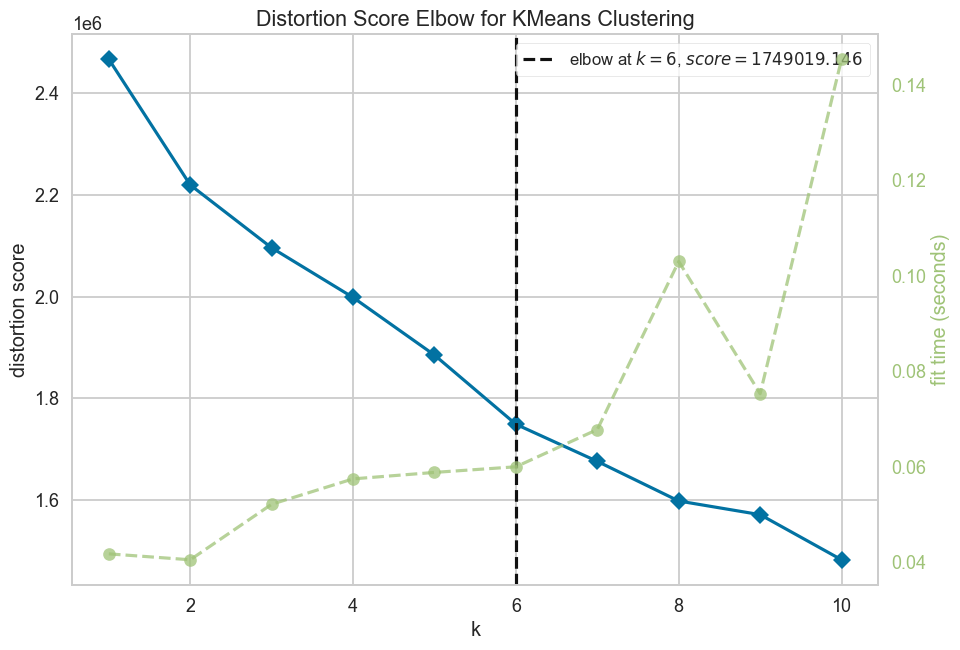

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [48]:
kmodel = KMeans(random_state=10)
elbowViz = KElbowVisualizer(kmodel, k=(1,11))
elbowViz.fit(scaled_df)
elbowViz.show()

**Retrain K-means model with newly chosen K**

In [49]:
hotKmeans = KMeans(n_clusters=6)
hotKmeans.fit(scaled_df)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### K-Means: Problems

- K-Means struggles with clusters of **different sizes**, **different densities**, or **non-spherical shapes**


##### Different Sizes

<img src="./img/clustering/size.png" width=100%>

##### Different Densities

<img src="./img/clustering/density.png" width=100%>

##### Non-Spherical Shapes

<img src="./img/clustering/shape.png" width=80%>

## Transition: From Partitioning to Hierarchy

**Limitation of K-Means:** You must pre-specify $K$ (number of clusters).

<div class="alert alert-warning">
    <strong>Business Question:</strong> What if we don't know how many segments exist?
    Or we want to explore segment structure at different granularities?
</div>

**Answer:** **Hierarchical clustering** — builds a tree of clusters,
letting you choose the granularity after the fact.

## Agglomerative Hierarchical Clustering

<dl class="row alert-danger">
    <dt class="col-md-4">Dendrogram</dt>
    <dd class="col-md-8">Shows cluster-subcluster relationships and order of merges/splits</dd>
</dl>

<img src="./img/clustering/dendrogram.png" width=80%>

> Methods for generating hierarchical clustering:

- **Agglomerative** (bottom-up)
  + Starts with each point as its own cluster; at each step, merge the two closest clusters

- **Divisive** (top-down)
  + Starts with all points in one cluster; at each step, split a cluster until each is a singleton

### Basic Algorithm

<center><img src="./img/clustering/agglomerativeCluster_en.svg" width=40%></center>

#### Proximity Matrix

<dl class="row alert-danger">
    <dt class="col-xl-4">Proximity Matrix</dt>
    <dd class="col-xl-8">A matrix of pairwise distances or similarities between clusters</dd>
</dl>

<p class="h5">Compute the proximity matrix for the following data, treating each sample as its own cluster:</p>

In [17]:
labels = [f'ID_{i}' for i in range(5)]
egDf = pd.DataFrame(np.random.random_sample([5,3])*10,columns=['X','Y','Z'],index=labels)
egDf

,X,Y,Z
ID_0,0.325567,3.233291,6.733970
ID_1,9.994812,4.265688,9.544987
ID_2,1.415994,8.184262,5.714814
ID_3,2.647324,2.847379,9.492347
ID_4,8.369117,2.332078,7.359324


In [18]:
from scipy.spatial.distance import pdist,squareform

```python
from scipy.spatial.distance import pdist,squareform
```
- `pdist(X, metric='euclidean')`: compute pairwise distances between data points
    - `metric`: distance measure: 'euclidean', 'mahalanobis', 'minkowski', 'cosine', 'jaccard', etc.
- `squareform(X)`: convert distance array to matrix form

In [19]:
pdist(egDf,metric='euclidean')

array([10.12234952,  5.17105594,  3.62603449,  8.11800209, 10.17946819,
        7.48331133,  3.34048685,  6.65343888,  9.23571346,  6.12815106])

In [20]:
rowDist = pd.DataFrame(squareform(pdist(egDf,metric='euclidean')),columns=labels,index=labels)
rowDist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,10.122350,5.171056,3.626034,8.118002
ID_1,10.122350,0.000000,10.179468,7.483311,3.340487
ID_2,5.171056,10.179468,0.000000,6.653439,9.235713
ID_3,3.626034,7.483311,6.653439,0.000000,6.128151
ID_4,8.118002,3.340487,9.235713,6.128151,0.000000


- Find the two clusters with the **smallest** distance in the matrix; merge them
- Recompute distances from the new cluster to others; update the matrix

#### Inter-Cluster Proximity Measures

- Computing distance between clusters:
    + Single linkage
    + Complete linkage
    + Average linkage
    + Ward Linkage
    + Centroid Linkage

##### Single Linkage

- Distance = **minimum** distance between any point in cluster A and any point in cluster B

<center><img src="./img/clustering/min.png" width=60%></center>

##### Complete Linkage

- Distance = **maximum** distance between any point in cluster A and any point in cluster B

<center><img src="./img/clustering/max.png" width=60%></center>

##### Average Linkage

- Distance = **average** distance between all pairs of points across the two clusters

<center><img src="./img/clustering/gpavg.png" width=60%></center>

##### Ward Linkage

- Computes the sum of squared errors (SSE) between two clusters
- Merges the pair that minimizes the **increase in SSE**

<center><img src="./img/clustering/wardLinkage.png" width=80%></center>

## Industry Standard Workflow for Hierarchical Clustering

<div class="alert alert-success">
    <strong>Two complementary libraries, one workflow.</strong> The industry standard pipeline uses <strong>SciPy</strong> for exploration (linkage matrix, dendrogram) and <strong>scikit-learn</strong> for production (consistent API). They are not competing methods — they are layers of the same stack.
</div>

```
  ┌─────────────────────────────────────────────────────────┐
  │  1. Compute linkage matrix (scipy.cluster.hierarchy)    │
  │  2. Visualize dendrogram (decide number of clusters)    │
  │  3. Cut tree → cluster labels                          │
  │     Option A: scipy.cluster.hierarchy.fcluster         │
  │     Option B: sklearn.cluster.AgglomerativeClustering  │
  └─────────────────────────────────────────────────────────┘
```

| Step | SciPy (exploration) | scikit-learn (production) |
|------|-------------------|--------------------------|
| **Compute** | `hierarchy.linkage()` | `AgglomerativeClustering.fit()` (internal) |
| **Visualize** | `hierarchy.dendrogram()` | Not available (use scipy) |
| **Cut tree** | `hierarchy.fcluster()` | `.fit_predict()` |
| **API style** | Array-oriented, manual | Estimator class, sklearn pipelines |

### Step 1: Compute Linkage Matrix (SciPy)

`scipy.cluster.hierarchy.linkage()` is the **foundation**. It computes the linkage matrix — a record of all merge events:

```python
from scipy.cluster import hierarchy
hierarchy.linkage(y, method='single', metric='euclidean')
```
- `y`: data matrix or distance vector from `pdist()`
- `method`: linkage criterion — `'single'`, `'complete'`, `'average'`, `'ward'`
- `metric`: distance metric — `'euclidean'` (most common)
- Returns: $(n-1) \times 4$ matrix — each row = one merge (cluster IDs, distance, size)

In [29]:
# --- Compute linkage matrix using average linkage ---
from scipy.cluster import hierarchy

# Subsample for speed
scaled_df_sample = scaled_df.sample(20000)

hotLink = hierarchy.linkage(scaled_df_sample, method='average', metric='euclidean')
hotLink

array([[6.57600000e+03, 1.21270000e+04, 0.00000000e+00, 2.00000000e+00],
       [7.20500000e+03, 1.72690000e+04, 0.00000000e+00, 2.00000000e+00],
       [4.19100000e+03, 1.65920000e+04, 0.00000000e+00, 2.00000000e+00],
       ...,
       [3.99860000e+04, 3.99950000e+04, 3.57528460e+01, 1.99980000e+04],
       [6.99100000e+03, 3.99960000e+04, 4.01526266e+01, 1.99990000e+04],
       [1.27290000e+04, 3.99970000e+04, 1.02961839e+02, 2.00000000e+04]],
      shape=(19999, 4))

Each row: **merge two clusters** → new cluster. `n_samples` = size of the new cluster. The merge order tells us the full hierarchy.

### Step 2: Visualize the Hierarchy (Dendrogram)

The dendrogram reveals the **natural cluster structure**. Use it to decide where to cut the tree.

```python
from scipy.cluster import hierarchy
hierarchy.dendrogram(Z, orientation='top', labels=None, ax=None)
```
- `Z`: linkage matrix from `hierarchy.linkage()`
- `labels`: tick labels for each leaf
- `orientation`: `'top'`, `'bottom'`, `'left'`, `'right'`

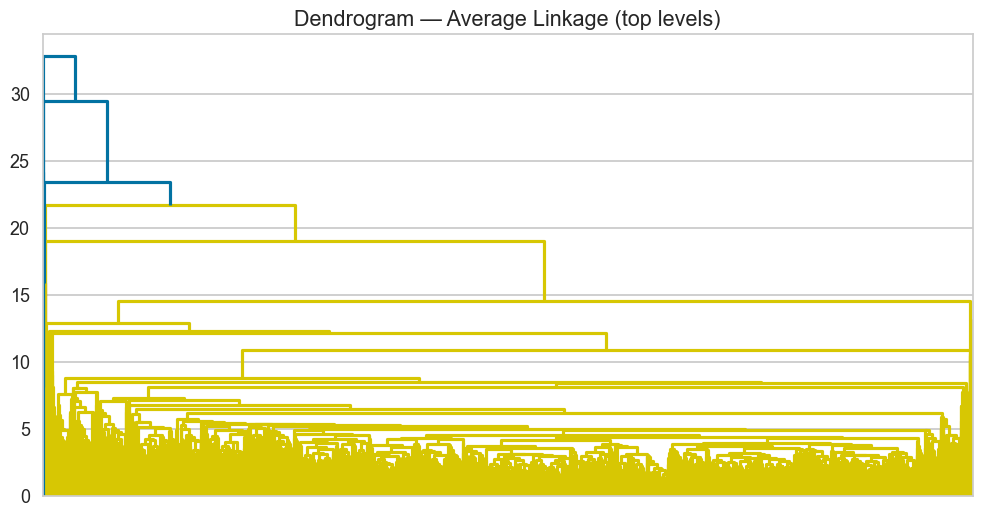

In [23]:
# --- Plot dendrogram (average linkage) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

cityDn = hierarchy.dendrogram(hotLink, ax=ax, color_threshold=0.7 * hotLink[-1, 2], no_labels=True, orientation='top')
# color_threshold = 0.7 * max_distance helps separate major clusters visually

ax.set_title('Dendrogram — Average Linkage (top levels)')
plt.show();

In [36]:
# Detect extreme outliers: rows whose largest |z-score| > 15.

zmax = np.abs(scaled_df_sample).max(axis=1)
print(f'Detected {(zmax > 3).sum()} extreme outlier(s); largest |z| = {zmax.max():.0f}')
scaled_df_sample = scaled_df_sample[zmax<3]
hotLink = hierarchy.linkage(scaled_df_sample, method='average', metric='euclidean')

Detected 4059 extreme outlier(s); largest |z| = 103


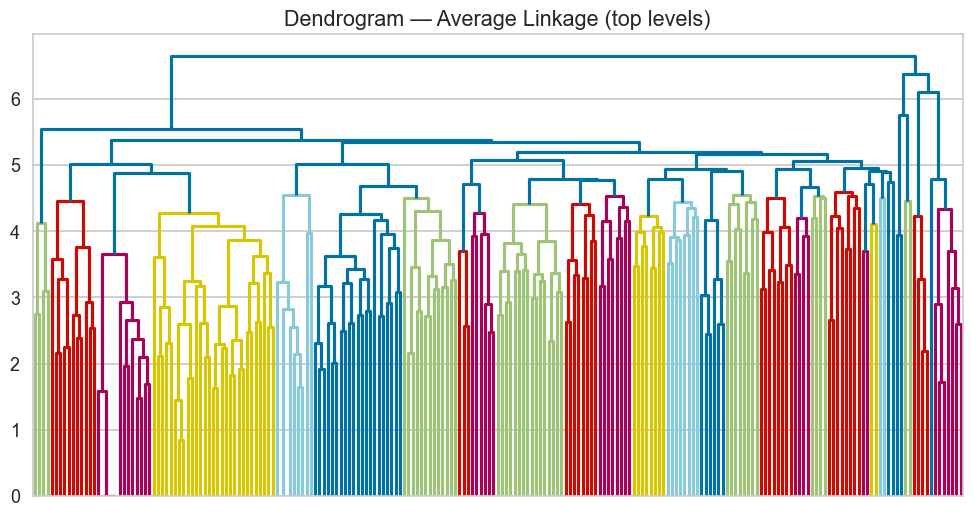

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

# truncate_mode='level', p=4 shows only the top 4 levels of the tree.
# A full 10000-leaf dendrogram otherwise renders as an unreadable wall of lines.

cityDn = hierarchy.dendrogram(hotLink, ax=ax,truncate_mode='level', p=10, color_threshold=0.7 * hotLink[-1, 2], no_labels=True, orientation='top')
# color_threshold = 0.7 * max_distance helps separate major clusters visually

ax.set_title('Dendrogram — Average Linkage (top levels)')
plt.show();

### Step 3: Cut the Tree → Get Cluster Labels

<div class="alert alert-info">
    <strong>Option A: SciPy</strong> — <code>hierarchy.fcluster(Z, t, criterion)</code>
</div>

After choosing $K$, cut the dendrogram at a given height or number of clusters:

```python
from scipy.cluster.hierarchy import fcluster
fcluster(Z, t, criterion='maxclust')
```
- `Z`: linkage matrix
- `t`: threshold (either cluster count or distance cutoff)
- `criterion`: `'maxclust'` (specify K) or `'distance'` (specify height)

In [38]:
# --- Cut the dendrogram at K=2 using fcluster (SciPy) ---
from scipy.cluster.hierarchy import fcluster

hotClusters_scipy = fcluster(hotLink, t=14, criterion='distance')

# Add to DataFrame
hotdf_scipy = scaled_df_sample.copy()
hotdf_scipy['cluster_scipy'] = hotClusters_scipy
hotdf_scipy

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,cluster_scipy
45223,-0.774241,-0.047559,-1.642142,1.684138,-0.432948,1.068112,-0.803292,0.289086,-0.261475,-0.080978,...,-0.086665,-0.341900,-0.132259,-0.635808,-0.255093,1.805038,-0.180542,-0.635808,-0.438396,1
44947,-0.774241,-0.066267,-1.642142,1.536815,0.819394,0.063849,-0.803292,-1.785174,-0.261475,-0.080978,...,-0.086665,1.237416,-0.132259,-0.681541,-0.255093,-0.721325,-0.575047,-0.681541,-0.667175,1
88188,-0.774241,-0.664920,-0.226837,-0.378383,0.705544,1.068112,-0.803292,-1.785174,-0.261475,-0.080978,...,-0.086665,1.237416,-0.132259,-0.110386,-0.255093,0.541857,-0.180542,-0.110386,-0.207232,1
6977,1.291587,0.130167,-0.226837,0.210909,0.819394,1.068112,0.252823,0.289086,-0.261475,-0.080978,...,-0.086665,-0.341900,-0.132259,2.042118,-0.255093,-0.721325,0.608467,2.042118,1.955959,1
114756,-0.774241,2.973771,1.188468,0.137248,0.705544,0.063849,-0.803292,0.289086,-0.261475,-0.080978,...,-0.086665,-0.341900,-0.132259,0.383532,-0.255093,0.541857,-0.575047,0.383532,-0.354783,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101419,-0.774241,-0.973601,-0.226837,1.757799,-0.432948,0.063849,-0.803292,0.289086,-0.261475,-0.080978,...,-0.086665,1.237416,-0.132259,-0.315677,-0.255093,1.805038,-0.575047,-0.315677,-0.559865,1
7124,1.291587,0.897192,-0.226837,0.358232,-1.685290,0.063849,0.252823,0.289086,-0.261475,-0.080978,...,-0.086665,-0.341900,-0.132259,1.407953,-0.255093,0.541857,0.213962,1.407953,0.975861,1
49487,1.291587,-0.421717,-0.226837,-0.673028,1.616339,0.063849,-0.803292,-1.785174,-0.261475,-0.080978,...,-0.086665,-0.341900,-0.132259,0.365238,-0.255093,-0.721325,-0.575047,0.365238,-0.360149,1
28478,-0.774241,-0.337532,-0.226837,1.168508,0.250147,-0.940413,-0.803292,0.289086,-0.261475,-0.080978,...,-0.086665,-0.341900,1.112298,-0.640890,-0.255093,-0.721325,-0.969552,-0.640890,-0.869872,1


### Step 3 (Alternative): Cut Tree with scikit-learn

<div class="alert alert-info">
    <strong>Option B: scikit-learn</strong> — <code>AgglomerativeClustering(n_clusters=4)</code>
</div>

`AgglomerativeClustering` **wraps** the same linkage + fcluster logic into a sklearn-compatible estimator. Use this when you want to stay within the sklearn ecosystem (e.g., pipelines, cross-validation).

In [41]:
# --- Build sklearn AgglomerativeClustering model ---
from sklearn.cluster import AgglomerativeClustering

hotAc = AgglomerativeClustering(
    n_clusters=14,          # same as fcluster(t=4, criterion='maxclust')
    metric='euclidean',  # same as metric='euclidean'
    linkage='ward'
)
hotAc

,n_clusters,14
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [42]:
# --- Train and predict in one step ---
hotAcLabels = hotAc.fit_predict(scaled_df_sample)
hotdf_scipy['cluster_sk'] = hotAcLabels
hotdf_scipy

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,cluster_scipy,cluster_sk
45223,-0.774241,-0.047559,-1.642142,1.684138,-0.432948,1.068112,-0.803292,0.289086,-0.261475,-0.080978,...,-0.341900,-0.132259,-0.635808,-0.255093,1.805038,-0.180542,-0.635808,-0.438396,1,6
44947,-0.774241,-0.066267,-1.642142,1.536815,0.819394,0.063849,-0.803292,-1.785174,-0.261475,-0.080978,...,1.237416,-0.132259,-0.681541,-0.255093,-0.721325,-0.575047,-0.681541,-0.667175,1,7
88188,-0.774241,-0.664920,-0.226837,-0.378383,0.705544,1.068112,-0.803292,-1.785174,-0.261475,-0.080978,...,1.237416,-0.132259,-0.110386,-0.255093,0.541857,-0.180542,-0.110386,-0.207232,1,12
6977,1.291587,0.130167,-0.226837,0.210909,0.819394,1.068112,0.252823,0.289086,-0.261475,-0.080978,...,-0.341900,-0.132259,2.042118,-0.255093,-0.721325,0.608467,2.042118,1.955959,1,11
114756,-0.774241,2.973771,1.188468,0.137248,0.705544,0.063849,-0.803292,0.289086,-0.261475,-0.080978,...,-0.341900,-0.132259,0.383532,-0.255093,0.541857,-0.575047,0.383532,-0.354783,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101419,-0.774241,-0.973601,-0.226837,1.757799,-0.432948,0.063849,-0.803292,0.289086,-0.261475,-0.080978,...,1.237416,-0.132259,-0.315677,-0.255093,1.805038,-0.575047,-0.315677,-0.559865,1,9
7124,1.291587,0.897192,-0.226837,0.358232,-1.685290,0.063849,0.252823,0.289086,-0.261475,-0.080978,...,-0.341900,-0.132259,1.407953,-0.255093,0.541857,0.213962,1.407953,0.975861,1,0
49487,1.291587,-0.421717,-0.226837,-0.673028,1.616339,0.063849,-0.803292,-1.785174,-0.261475,-0.080978,...,-0.341900,-0.132259,0.365238,-0.255093,-0.721325,-0.575047,0.365238,-0.360149,1,0
28478,-0.774241,-0.337532,-0.226837,1.168508,0.250147,-0.940413,-0.803292,0.289086,-0.261475,-0.080978,...,-0.341900,1.112298,-0.640890,-0.255093,-0.721325,-0.969552,-0.640890,-0.869872,1,6



<div class="alert alert-success">
    <strong>Industry Standard:</strong> Use SciPy to <strong>explore</strong> (dendrogram + linkage matrix inspection), then switch to sklearn for <strong>production</strong> (fit_predict + pipelines). The underlying algorithm is <strong>identical</strong>.
</div>

### Limitations of Hierarchical Clustering

- Once merged, clusters cannot be separated (no backtracking)

- No global objective function to optimize

## Clustering Validation

### Are Our Clusters Any Good?

**Business Question:** How do we know if our customer segments are meaningful?

<div class="alert alert-info">
    <strong>Key Insight:</strong> Good clusters have high <strong>cohesion</strong>
    (similar within) and high <strong>separation</strong> (distinct from others).
</div>

We need **clustering validation** metrics.

- Evaluation approaches:
  + **Supervised** (external): uses ground-truth labels (e.g., class labels) to judge cluster quality
  + **Unsupervised** (internal): uses only the data itself to judge cluster quality

### Unsupervised (Internal) Validation

<dl class="row alert-info">
    <dt class="col-lg-4">Cohesion</dt>
    <dd class="col-lg-8">How closely related points within a cluster are</dd>
</dl>

- Measured as mean pairwise distance ***within*** a cluster

<dl class="row alert-danger">
    <dt class="col-lg-4">Separation</dt>
    <dd class="col-lg-8">How distinct a cluster is from others</dd>
</dl>

- Measured as mean distance ***between*** points in different clusters

<center><img src="./img/clustering/cohesionSeparation.png" width=60%></center>

### Silhouette Coefficient

<center><img src="./img/clustering/silhouette.png" width=40%></center>

- $a_i$ = mean distance from point $i$ to all other points in its own cluster

- For each other cluster, compute mean distance from point $i$ to all points in that cluster
- $b_i$ = the **minimum** of these mean distances across all other clusters

$$
s_i = \frac{b_i-a_i}{\max(a_i,b_i)}
$$

$s_i\in[-1,1]$

- Values close to +1 indicate well-separated clusters
- Values near 0 indicate overlapping clusters
- Negative values suggest points may be in the wrong cluster

#### Python Implementation

```python
from sklearn.metrics import silouette_samples, silhouette_score
```

```python
silhouette_samples(X, labels, metric=’euclidean’)
```
- `X`: the data matrix used for clustering
- `labels`: cluster labels assigned by the clustering algorithm
- Returns: array of silhouette values, shape `[n_samples]`

```python
silhouette_score(X, labels, metric=’euclidean’)
```
- `X`: the data matrix used for clustering
- `labels`: cluster labels assigned by the clustering algorithm
- Returns: `float`, average silhouette score across all samples

In [43]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [44]:
hotAcSilhouetteVals = silhouette_samples(hotdf_scipy,hotAcLabels)
hotAcSilhouetteVals

array([0.22941091, 0.22849226, 0.31785381, ..., 0.18825828, 0.15887889,
       0.34484167], shape=(15941,))

In [45]:
hotAcSilhouetteScore = silhouette_score(hotdf_scipy,hotAcLabels)
hotAcSilhouetteScore

0.21003301483566839

- `silhouette_score` = **mean** of `silhouette_samples`

In [46]:
hotAcSilhouetteVals.mean()

np.float64(0.21003301483566839)

#### Silhouette Plot

- Sort silhouette values within each cluster; plot as horizontal bar chart

- A good clustering has **roughly equal bar widths and heights** across clusters

```python
from yellowbrick.cluster import SilhouetteVisualizer
silviz = SilhouetteVisualizer(estimator, colors=None)
silviz.fit(X)
silviz.show()
```
- `estimator`: the clustering model
- `color`: color palette — `Yellowbrick` or `matplotlib` colormap. Reference: [Yellowbrick Palettes](https://www.scikit-yb.org/en/latest/api/palettes.html)

,estimator,KMeans(n_clusters=6)
,ax,<Axes: >
,colors,None
,is_fitted,'auto'
,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None


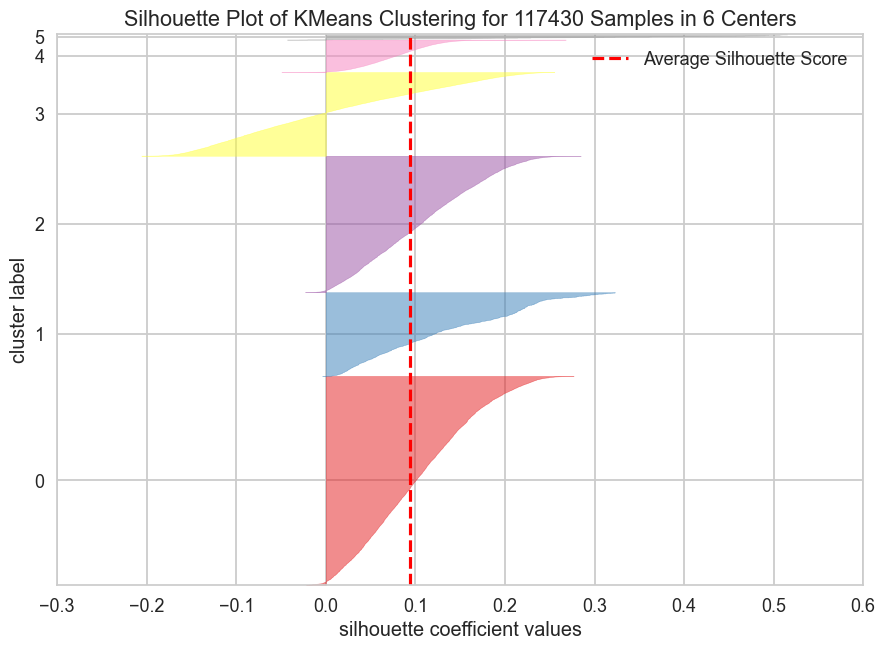

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 117430 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [50]:
silViz = SilhouetteVisualizer(hotKmeans, color='yellowbrick')
silViz.fit(scaled_df)
silViz.show()

<div class="alert alert-warning">
    <strong>Requirement:</strong> The estimator must implement `predict(X)`.
    `KMeans` does; `AgglomerativeClustering` does <strong>not</strong> — use the `AgglomerativeAdapter` class above.
</div>

<div class="alert alert-success">
    <strong>Solution:</strong> Wrap the model in a small adapter class that implements `fit` + `predict`. For hierarchical clustering, `predict` returns the cluster labels learned during `fit`.
</div>

In [52]:
# --- Adapter: make AgglomerativeClustering compatible with Yellowbrick ---
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import AgglomerativeClustering

class AgglomerativeAdapter(BaseEstimator, ClusterMixin):
    """Wrapper giving AgglomerativeClustering a predict() method.
    AgglomerativeClustering cannot label NEW points, so predict()
    returns the labels learned during fit()."""
    def __init__(self, n_clusters=2, metric='euclidean', linkage='average'):
        self.n_clusters = n_clusters
        self.metric = metric
        self.linkage = linkage

    def fit(self, X, y=None):
        self.model = AgglomerativeClustering(
            n_clusters=self.n_clusters,
            metric=self.metric,
            linkage=self.linkage,
        )
        self.model.fit(X)
        self.labels_ = self.model.labels_
        return self

    def predict(self, X):
        # Yellowbrick calls predict(X) on the same data used in fit()
        return self.labels_

,estimator,Agglomerative...n_clusters=14)
,ax,<Axes: >
,colors,None
,is_fitted,'auto'
,n_clusters,14
,metric,'euclidean'
,linkage,'ward'


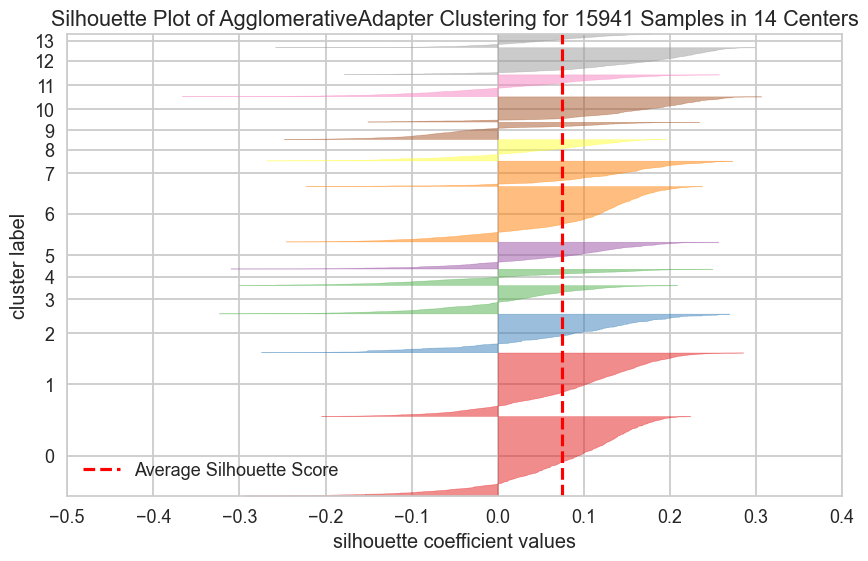

<Axes: title={'center': 'Silhouette Plot of AgglomerativeAdapter Clustering for 15941 Samples in 14 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [53]:
# --- Silhouette plot for hierarchical clustering ---
from yellowbrick.cluster import SilhouetteVisualizer

# Wrap the same model (n_clusters=2, average linkage) used earlier
hotAcAdapter = AgglomerativeAdapter(n_clusters=14, metric='euclidean', linkage='ward')

fig, ax = plt.subplots(figsize=(10, 6))
silViz = SilhouetteVisualizer(hotAcAdapter, ax=ax, color='yellowbrick')
silViz.fit(scaled_df_sample)
silViz.show()

## Additional Clustering Evaluation Criteria

### Davies-Bouldin Index (DBI)

<dl class="row alert-info">
    <dt class="col-md-3">Idea</dt>
    <dd class="col-md-9">Ratio of within-cluster scatter to between-cluster separation</dd>
</dl>

$$
DBI = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(c_i, c_j)} \right)
$$

- $\sigma_i$: average distance from points in cluster $i$ to its centroid
- $d(c_i, c_j)$: distance between centroids of clusters $i$ and $j$

<p class="text-danger"><strong>Lower is better.</strong> DBI = 0 means perfect separation.</p>

Built-in: `sklearn.metrics.davies_bouldin_score`

In [54]:
from sklearn.metrics import davies_bouldin_score

hotDBI = davies_bouldin_score(scaled_df, hotKmeans.labels_)
print(f'Davies-Bouldin Index: {hotDBI:.4f}')
print('(Lower is better; 0 = perfect separation)')

Davies-Bouldin Index: 2.0010
(Lower is better; 0 = perfect separation)


### Calinski-Harabasz Index (CHI)

<dl class="row alert-info">
    <dt class="col-md-3">Idea</dt>
    <dd class="col-md-9">Ratio of between-cluster variance to within-cluster variance</dd>
</dl>

Also called the **Variance Ratio Criterion**:

$$
CHI = \frac{\text{tr}(B_k)}{\text{tr}(W_k)} \times \frac{N - k}{k - 1}
$$

- $B_k$: between-cluster dispersion matrix
- $W_k$: within-cluster dispersion matrix
- $N$: total samples, $k$: number of clusters

<p class="text-success"><strong>Higher is better.</strong> Well-separated dense clusters yield high CHI.</p>

Built-in: `sklearn.metrics.calinski_harabasz_score`

In [55]:
from sklearn.metrics import calinski_harabasz_score

hotCHI = calinski_harabasz_score(scaled_df, hotKmeans.labels_)
print(f'Calinski-Harabasz Index: {hotCHI:.2f}')
print('(Higher is better; well-separated dense clusters)')

Calinski-Harabasz Index: 7903.41
(Higher is better; well-separated dense clusters)


### Choosing the Right Metric

| Metric | Range | Direction | Key Property | Best Use Case |
|--------|-------|-----------|-------------|---------------|
| **Silhouette** | $[-1, 1]$ | Higher $\uparrow$ | Measures cohesion vs. separation | General-purpose; interpretable per-point |
| **Davies-Bouldin** | $[0, \infty)$ | Lower $\downarrow$ | Ratio of cluster scatter to centroid distance | Datasets with well-separated centroids |
| **Calinski-Harabasz** | $[0, \infty)$ | Higher $\uparrow$ | Variance ratio (ANOVA-like) | Spherical clusters of similar density |

<div class="alert alert-warning">
    <strong>Best Practice:</strong> Never rely on a single metric. Use 2-3 metrics together and look for consensus. Each metric has mathematical biases — Silhouette favors convex clusters, CHI favors equal-size clusters, DBI is sensitive to centroid quality.
</div>

**Pro Tip:** When choosing $K$, plot all three metrics side-by-side and look for regions where multiple metrics agree.

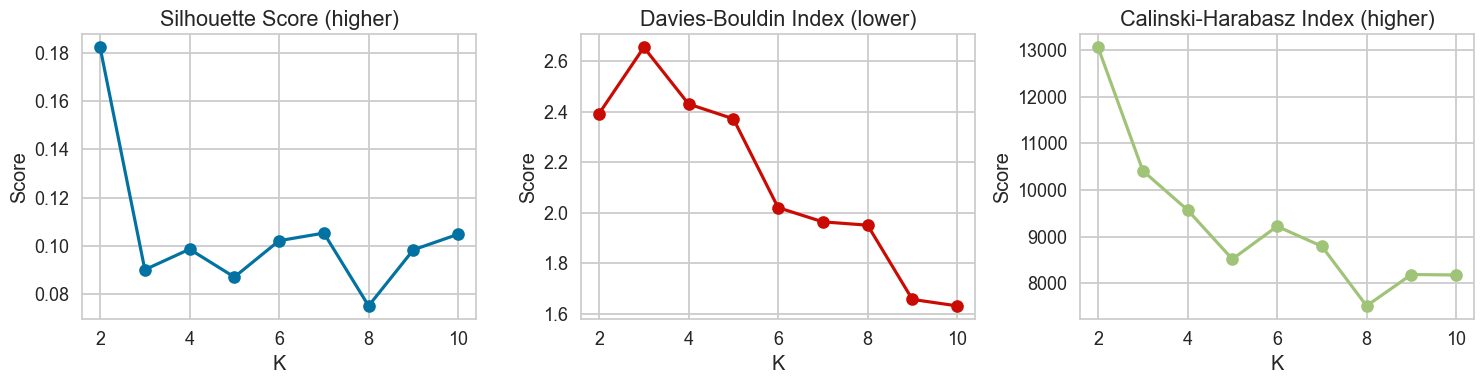

In [56]:
Ks = range(2, 11)
sil_scores, dbi_scores, chi_scores = [], [], []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = km.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, labels))
    dbi_scores.append(davies_bouldin_score(scaled_df, labels))
    chi_scores.append(calinski_harabasz_score(scaled_df, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(Ks, sil_scores, 'bo-')
axes[0].set_title('Silhouette Score (higher)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Score')

axes[1].plot(Ks, dbi_scores, 'ro-')
axes[1].set_title('Davies-Bouldin Index (lower)')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')

axes[2].plot(Ks, chi_scores, 'go-')
axes[2].set_title('Calinski-Harabasz Index (higher)')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show();

## Visualizing Cluster Structure

<div class="alert alert-info">
    <strong>Goal:</strong> Turn high-dimensional cluster assignments into a 2D/3D picture stakeholders can read instantly.
</div>

- Project high-dimensional data into low-dimensional space (2D or 3D)

- The key is **preserving similarity relationships** from high-dimensional space: points that are similar should land close together in the plot

### Three Families of Methods

| Family | Methods | Core idea |
|--------|---------|-----------|
| **Linear** | PCA, classical MDS | Preserve global variance / pairwise distances |
| **Nonlinear (neighborhood)** | t-SNE, UMAP | Preserve local neighborhoods |
| **Cluster-specific** | Yellowbrick `InterclusterDistance` | Embed *cluster centers*, not individual points |

### MDS — Multi-Dimensional Scaling

<dl class="row alert-info">
    <dt class="col-md-3">Idea</dt>
    <dd class="col-md-9">Place points in low-dimensional space so that the **pairwise distances** in the plot match the pairwise distances in the original space as closely as possible.</dd>
</dl>

Minimize the stress function:

$$
\text{Stress} = \sqrt{\frac{\sum_{i<j}\left(d_{ij} - \hat d_{ij}\right)^2}{\sum_{i<j} d_{ij}^2}}
$$

- $d_{ij}$: distance between points $i$ and $j$ in original space
- $\hat d_{ij}$: distance between the same two points in the 2D plot
- **Classical MDS** (metric, Euclidean distance) is equivalent to **PCA** — both are linear projections

<div class="alert alert-success">
    <strong>Strengths:</strong> deterministic (same result every run), preserves <strong>global</strong> structure, fast, easy to interpret.
</div>

<div class="alert alert-danger">
    <strong>Limitations:</strong> linear — cannot capture **nonlinear** cluster shapes (e.g., concentric rings, Swiss roll). Points from different clusters may overlap in the projection.
</div>

<p><strong>Best for:</strong> when cluster structure is roughly linear / globally separated.</p>

### t-SNE — t-Distributed Stochastic Neighbor Embedding

<dl class="row alert-info">
    <dt class="col-md-3">Idea</dt>
    <dd class="col-md-9">Convert pairwise similarities into **probabilities**, then find a low-dimensional layout where the two probability distributions match.</dd>
</dl>

$$
p_{j|i} = \frac{\exp\left(-\|\boldsymbol{x}_i - \boldsymbol{x}_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|\boldsymbol{x}_i - \boldsymbol{x}_k\|^2 / 2\sigma_i^2\right)}
$$

- **High-dimensional** similarities: Gaussian probabilities ($p_{j|i}$)
- **Low-dimensional** similarities: heavy-tailed $t$-distribution with 1 dof ($q_{ij}$)
- **Goal:** minimize the Kullback–Leibler divergence $KL(P\|Q)$ between the two
- Key hyperparameter: **perplexity** (~5-50) — controls the effective neighborhood size

<div class="alert alert-success">
    <strong>Strengths:</strong> captures <strong>nonlinear</strong> structure; excellent at revealing local cluster neighborhoods that linear methods miss.
</div>

<div class="alert alert-danger">
    <strong>Limitations:</strong>
    <ul>
        <li><strong>Global distances are meaningless</strong> — only local neighborhoods are preserved</li>
        <li><strong>Non-deterministic</strong> — different runs give different plots (set <code>random_state</code>)</li>
        <li><strong>Slow</strong> on large datasets</li>
        <li><strong>Can create illusionary clusters</strong> in uniform noise — always sanity-check</li>
    </ul>
</div>

### UMAP — Uniform Manifold Approximation and Projection

<dl class="row alert-info">
    <dt class="col-md-3">Idea</dt>
    <dd class="col-md-9">Build a weighted graph of local neighborhoods, then embed it in low dimension — balancing **local and global** structure.</dd>
</dl>

**The modern standard for cluster visualization** — fast, scalable, and usually produces tighter, more readable clusters than t-SNE.

<dl class="row">
    <dt class="col-md-3"><code>n_neighbors</code></dt>
    <dd class="col-md-9">Size of the local neighborhood: small → fine detail / micro-clusters, large → global structure.</dd>
    <dt class="col-md-3"><code>min_dist</code></dt>
    <dd class="col-md-9">Minimum distance between points in the embedding: small → tight, packed clusters.</dd>
</dl>


In [ ]:
# --- UMAP embedding of the hotel guests (install: pip install umap-learn) ---
from umap import UMAP
import numpy as np
import matplotlib.pyplot as plt

# Subsample so the embeddings (O(n^2)) stay fast on this dataset
rng = np.random.RandomState(42)
sample = rng.choice(len(scaled_df), 1000, replace=False)
sample_df = scaled_df.iloc[sample].copy()
sample_labels = hotAcLabels[sample]

umap_emb = UMAP(n_neighbors=50, min_dist=0.1, random_state=42).fit_transform(sample_df)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(umap_emb[:, 0], umap_emb[:, 1], c=sample_labels, cmap="Set1", s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Projection of Hotel Guests (subsample of 1000)')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.show();

<p class="h3">How to Read This Plot</p>

<dl class="row">
    <dt class="col-md-4 text-primary">Separation</dt>
    <dd class="col-md-8">Distinct colored blobs = clusters are <strong>well separated</strong> in the original feature space. Overlapping colors = segments blend into each other.</dd>
    <dt class="col-md-4 text-success">Density</dt>
    <dd class="col-md-8">Tightly packed points = a coherent, homogeneous segment. Sparse, scattered points = a diffuse segment.</dd>
    <dt class="col-md-4 text-warning">Gaps</dt>
    <dd class="col-md-8">Empty space between blobs hints at a boundary — but UMAP can stretch gaps, so confirm with silhouette or DBI before trusting them.</dd>
    <dt class="col-md-4 text-danger">Bridges</dt>
    <dd class="col-md-8">Points connecting two blobs are <strong>boundary customers</strong> — they sit between segments and are the first to switch.</dd>
</dl>


#### What the Axes Do NOT Mean

<div class="alert alert-danger">
    <strong>UMAP-1 and UMAP-2 have no physical units.</strong> They are <strong>arbitrary abstract axes</strong> — their scale, sign, and rotation carry no meaning. Only <strong>relative distances and adjacency</strong> between points matter, never the axis values themselves.
</div>


#### Common Pitfall: Over-Interpreting UMAP

<dl class="row">
    <dt class="col-md-4 text-danger">Trap 1</dt>
    <dd class="col-md-8"><strong>"Gaps are real clusters."</strong> UMAP can stretch gaps between dense regions — a visual gap does <strong>not</strong> prove a strong boundary. Confirm with a silhouette or Davies-Bouldin score.</dd>
    <dt class="col-md-4 text-danger">Trap 2</dt>
    <dd class="col-md-8"><strong>"Distance means similarity."</strong> Distances in UMAP space are <strong>not proportional</strong> to original distances — only relative proximity is meaningful.</dd>
    <dt class="col-md-4 text-danger">Trap 3</dt>
    <dd class="col-md-8"><strong>"Cluster size means market share."</strong> Blob density depends on <code>n_neighbors</code>/<code>min_dist</code>, not just the data — never read revenue from plot size.</dd>
</dl>


In [ ]:
# --- Bonus: how n_neighbors changes the picture ---
# Run 3 UMAPs with different neighborhood sizes side-by-side
# from umap import UMAP
#
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for ax, nn in zip(axes, [5, 15, 50]):
#     emb = UMAP(n_neighbors=nn, min_dist=0.1, random_state=42).fit_transform(sample_df)
#     ax.scatter(emb[:, 0], emb[:, 1], c=sample_labels, cmap='Set1', s=40, alpha=0.8)
#     ax.set_title(f'n_neighbors = {nn}')
#     ax.set_xticks([]); ax.set_yticks([])
# plt.tight_layout()
# plt.show()
#
# # Observation: small n_neighbors -> fragmented micro-clusters; large -> merged, smoother blobs


### Which Method Should You Use?

| Method | Global structure | Local clusters | Deterministic | Speed | Verdict |
|--------|:---:|:---:|:---:|:---:|--------|
| **PCA** | ✅ Strong | Weak | ✅ | ✅✅ | Baseline sanity check |
| **MDS** | ✅ Strong | Weak | ✅ | ✅✅ | Good when structure is linear |
| **t-SNE** | ❌ Weak | ✅ Strong | ❌ | ⚠️ | Local-neighborhood explorer |
| **UMAP** | ⚠️ Partial | ✅ Strong | ⚠️ | ✅✅ | Modern default for cluster views |

**Rule of thumb:** use **UMAP** as the default; fall back to **MDS** when you need a deterministic, distance-faithful view; use **PCA** for a quick sanity check.


## Posthoc Visualization of the Obtained Clusters

<div class="alert alert-info">
    <strong>Clarification:</strong> MDS, t-SNE, and UMAP are ALL unsupervised — none uses cluster labels during embedding. Clusters are overlaid **afterward** by coloring each embedded point with its cluster label. This is called **posthoc visualization**.
</div>

Why MDS/t-SNE tend to "respect" distance-based clusters (K-Means, hierarchical):

- **MDS** preserves **global pairwise distances** → points from different clusters stay far apart, just as they are in feature space
- **t-SNE** preserves **local neighborhoods** → members of the same cluster (close neighbors) stay close
- **UMAP** balances both, but can reveal manifold structure that disagrees with spherical K-Means clusters

<div class="alert alert-success">
    <strong>Practice:</strong> Always run the embedding on `X` alone, then color by cluster labels. If colored blobs are well separated, the clustering agrees with the data geometry.
</div>

#### MDS Embedding, Colored by Cluster Labels

`sklearn.manifold.MDS` projects the data preserving pairwise distances — a good posthoc check for distance-based clustering:

In [ ]:
# --- MDS embedding (preserves global distances, on the same subsample) ---
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt

# Subsample so the embeddings (O(n^2)) stay fast on this dataset
rng = np.random.RandomState(42)
sample = rng.choice(len(scaled_df), 1000, replace=False)
sample_df = scaled_df.iloc[sample].copy()
sample_labels = hotAcLabels[sample]

mds = MDS(n_components=2, random_state=42, dissimilarity="euclidean")
mds_emb = mds.fit_transform(sample_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(mds_emb[:, 0], mds_emb[:, 1],
                      c=sample_labels, cmap="Set1", s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('MDS Embedding of Hotel Guests (colored by hierarchical cluster)')
plt.xlabel('MDS-1'); plt.ylabel('MDS-2')
plt.show();

#### t-SNE Embedding, Colored by Cluster Labels

`sklearn.manifold.TSNE` preserves local neighborhoods — members of the same cluster should stay grouped:

In [ ]:
# --- t-SNE embedding (preserves local neighborhoods, same subsample) ---
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_emb = tsne.fit_transform(sample_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                      c=sample_labels, cmap="Set1", s=50, alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE Embedding of Hotel Guests (colored by hierarchical cluster)')
plt.xlabel('t-SNE-1'); plt.ylabel('t-SNE-2')
plt.show();

#### Comparing the Three Views

| Method | What it preserves | Alignment with distance clusters |
|--------|-------------------|--------------------------------|
| **MDS** | Global distances | Strong (clusters defined by distance) |
| **t-SNE** | Local neighborhoods | Strong (same-cluster points are neighbors) |
| **UMAP** | Local + global manifold | Medium (may reveal non-spherical structure) |

<div class="alert alert-warning">
    <strong>When they disagree:</strong> If MDS/t-SNE show clean colored blobs but UMAP shows scattered/overlapping colors, the data likely has **non-spherical or curved cluster structure** that K-Means/hierarchical clustering missed — a signal to try DBSCAN (Part II).
</div>

<div class="alert alert-success">
    <strong>Truly label-aware alternative:</strong> For a projection that actively uses cluster labels, use <strong>LDA</strong> (Linear Discriminant Analysis) or embed only the **cluster centers** via Yellowbrick's `InterclusterDistance` (next slide).
</div>

### Cluster-Center View: Yellowbrick `InterclusterDistance`

Instead of embedding every point, this embeds only the **cluster centers** with MDS or t-SNE, and sizes each bubble by cluster membership:

```python
InterclusterDistance(estimator, embedding='mds', scoring='membership', random_state=None)
```
- `estimator`: a model that exposes `cluster_centers_`, i.e. **KMeans only** —
  AgglomerativeClustering has no `cluster_centers_` (there is no centroid), so this
  visualizer **cannot** be used for hierarchical clustering.
- `embedding`: `'mds'` or `'tsne'` (Yellowbrick does not support UMAP here)
- `scoring`: `'membership'` sizes bubbles by cluster count

<div class="alert alert-info">
    <strong>Note:</strong> This is the most "cluster-aware" of the four views because it operates on the learned cluster centers rather than raw points.
</div>

<div class="alert alert-warning">
    <strong>Pitfall:</strong> Prefer <code>embedding='mds'</code> when there are few clusters. <code>embedding='tsne'</code> raises
    <code>ValueError: perplexity (30.0) must be less than n_samples</code> because t-SNE requires <code>perplexity &lt; n_samples</code>,
    and here only the 2 cluster centers are embedded.
</div>

In [ ]:
# --- Embed cluster centers with MDS (works for ANY number of clusters) ---
from yellowbrick.cluster import InterclusterDistance

idVis = InterclusterDistance(hotKmeans, embedding='mds', random_state=10)
idVis.fit(scaled_df)
idVis.show()

# Note: embedding="tsne" FAILS here. t-SNE needs perplexity (default 30)
# to be smaller than the number of samples, but there are only 2 cluster centers.

## Summary

| Aspect | Key Takeaway |
|--------|-------------|
| **What** | Clustering groups unlabeled data by similarity |
| **Why for business** | Customer segmentation, targeted marketing, anomaly detection |
| **K-Means** | Fast partitioning; needs K; works for spherical clusters |
| **Hierarchical** | Builds dendrogram; no K needed upfront; computationally heavier |
| **Validation** | Silhouette score: +1 = excellent, 0 = overlapping, -1 = wrong cluster |
| **Visualization** | MDS/t-SNE/UMAP project high-dim clusters to 2D for stakeholders |

<div class="alert alert-info">
    <strong>Business Recommendation:</strong> Start with K-Means for quick segmentation.
    Use hierarchical clustering when you need to explore granularity.
    Always validate with silhouette score.
</div>